# Transformer dự báo giá đối thủ — TP.HCM

> Trả lời câu hỏi của mentor: *"Các em đã test thử neural network transformer thử chưa?"*

---

## Giả thuyết cần kiểm

Model hiện tại nén **60 phút lịch sử giá** thành **3 con số** `mean · std · slope`.
Hình dạng chuỗi bị vứt đi:

```
A:  100 → 102 → 104 → 106 → 108      tăng đều, thị trường ổn định
B:  108 → 100 → 108 → 100 → 108      giật cục, thị trường bất ổn
```

Ba con số của A và B gần như y hệt, nhưng ý nghĩa khác hẳn. **Transformer đọc thẳng chuỗi nên
phân biệt được.** Nếu chuỗi có tín hiệu mà 3 con số làm mất, transformer sẽ thắng.

## Kiến trúc tổng quát

```
        ┌──────────────── ĐẦU VÀO ────────────────┐
        │                                          │
   CHUỖI 32 bước × 7 feature            TĨNH (chuyến cần đoán)
   (32 báo giá gần nhất, trước mốc cắt)  14 số + 5 danh mục
        │                                          │
        ▼                                          ▼
   Linear → d_model                         Embedding danh mục
        │                                          │
   + Positional Embedding                          │
        │                                          │
        ▼                                          │
   ┌─────────────────────────┐                     │
   │  TRANSFORMER ENCODER    │                     │
   │  × 2 lớp                │                     │
   │   ├ Multi-head Attention│                     │
   │   ├ Feed-Forward        │                     │
   │   └ LayerNorm + Residual│                     │
   └─────────────────────────┘                     │
        │                                          │
   Mean pool (bỏ bước đệm)                         │
        │                                          │
        └──────────────┬───────────────────────────┘
                       ▼
                  Nối lại → MLP
                       │
              ┌────────┴────────┐
              ▼                 ▼
      log(giá cơ bản)      hệ số nhân
              └────────┬────────┘
                       ▼
              giá = exp(base) × hệ số
```

**Vì sao hai đầu ra thay vì một:** kiến trúc Hybrid đang dùng tách giá thành
`giá cơ bản × hệ số nhân`, và đã chứng minh tốt hơn dự đoán trực tiếp (18.048đ vs 18.834đ).
Phân tích ceteris paribus cho thấy hai target phụ thuộc **hai nhóm yếu tố rời nhau**:
quãng đường/thời lượng → 100% vào giá cơ bản, cung–cầu → 100% vào hệ số nhân.

## Mốc phải vượt

| Model | MAE | MAPE |
|---|---:|---:|
| Persistence (dùng thẳng giá quan sát) | 33.683đ | — |
| Dự đoán giá trực tiếp (GBM) | 18.834đ | — |
| **Hybrid GBM** (đang dùng) | **18.048đ** | **14,74%** |

## Nội dung notebook

| Phần | Nội dung |
|---|---|
| 1 | Tham số cấu hình |
| 2 | Dữ liệu đầu vào — dựng chuỗi |
| 3 | Kiến trúc chi tiết từng tầng |
| 4 | Huấn luyện |
| 5 | Trực quan quá trình huấn luyện |
| 6 | Đánh giá trên tập test |
| 7 | Trực quan kết quả |
| 8 | Xuất model để tải về máy |

> ⚠️ Bật GPU: **Settings → Accelerator → GPU T4 x2**

## 1. Tham số cấu hình

Gom hết vào một chỗ để dễ thử cấu hình khác.

In [14]:
CAU_HINH = {
    # ── Chuỗi ────────────────────────────────────────────────
    "K": 32,               # số báo giá gần nhất đưa vào chuỗi

    # ── Kiến trúc ────────────────────────────────────────────
    "d_model": 64,         # chiều biểu diễn trong transformer
    "n_lop": 2,            # số lớp encoder
    "n_head": 4,           # số đầu attention
    "d_ff": 128,           # chiều lớp feed-forward
    "dropout": 0.10,
    "d_mlp": 128,          # chiều lớp MLP sau khi nối

    # ── Huấn luyện ───────────────────────────────────────────
    "epochs": 50,
    "batch": 2048,
    "lr": 2e-3,
    "weight_decay": 1e-4,
    "clip_grad": 1.0,
    "seed": 42,
    "kien_nhan": 8,        # dừng sớm nếu 8 epoch liền không cải thiện

    # ── Khác ─────────────────────────────────────────────────
    "thang": [1, 2, 3],    # train riêng từng tháng (lịch sử giá reset theo tháng)
    "ty_le_valid": 0.05,   # cắt từ train để theo dõi overfit
}

MOC = {"persistence": 33683, "truc_tiep": 18834, "hybrid": 18048, "hybrid_mape": 0.1474}

import os, json, time, math, gc, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(CAU_HINH["seed"]); np.random.seed(CAU_HINH["seed"])
DEV = "cuda" if torch.cuda.is_available() else "cpu"

print(f"torch {torch.__version__} · thiết bị: {DEV}")
if DEV == "cuda":
    print(f"  {torch.cuda.get_device_name(0)} · "
          f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
else:
    print("  ⚠️ Chưa bật GPU — Settings > Accelerator > GPU T4 x2")
print()
for k, v in CAU_HINH.items():
    print(f"  {k:14s} {v}")

torch 2.10.0+cu128 · thiết bị: cuda
  Tesla T4 · 14.6 GB

  K              32
  d_model        64
  n_lop          2
  n_head         4
  d_ff           128
  dropout        0.1
  d_mlp          128
  epochs         50
  batch          2048
  lr             0.002
  weight_decay   0.0001
  clip_grad      1.0
  seed           42
  kien_nhan      8
  thang          [1, 2, 3]
  ty_le_valid    0.05


## 2. Dữ liệu đầu vào

### Hai bảng nguồn

| Bảng | Số dòng | Vai trò |
|---|---:|---|
| `mau.parquet` | 6.897.051 | Mỗi dòng là **một bài toán dự đoán** — có mốc cắt `cutoff` |
| `bao_gia.parquet` | 1.724.714 | **Dòng chảy báo giá**, đã sắp theo `(luồng, thời gian)` |

Tách hai bảng vì nếu nhúng sẵn chuỗi vào từng dòng thì tốn **5,8 GB**; tra cứu lúc chạy chỉ
tốn **175 MB**.

### Ba nhóm đầu vào của model

| Nhóm | Kích thước | Nội dung |
|---|---|---|
| **Chuỗi** | 32 × 7 | Báo giá quá khứ: `giá · hệ số · km · phút · mất cân bằng · cầu · cung` |
| **Tĩnh (số)** | 14 | Chuyến cần đoán + tóm tắt lịch sử |
| **Tĩnh (danh mục)** | 5 | `xe · điểm đón · điểm trả · thời tiết · giờ` |

Nhóm tĩnh **đúng bằng bộ feature của model production**, nên transformer được ăn mọi thứ model
hiện tại đang ăn, **cộng thêm chuỗi**.

> **Lưu ý:** `km` xuất hiện ở cả chuỗi lẫn tĩnh nhưng khác nghĩa — trong chuỗi là quãng đường của
> **chuyến đối thủ đã chào trong quá khứ**, trong tĩnh là quãng đường của **chuyến đang cần đoán**.

In [15]:
DUONG = None
for goc, _, fs in os.walk("/kaggle/input"):
    if "mau.parquet" in fs:
        DUONG = goc; break
if DUONG is None:
    DUONG = "."   # chạy local
assert os.path.exists(f"{DUONG}/mau.parquet"), "Không thấy mau.parquet — đã Add Input chưa?"
print("Thư mục dữ liệu:", DUONG)

mau = pd.read_parquet(f"{DUONG}/mau.parquet")
bg = pd.read_parquet(f"{DUONG}/bao_gia.parquet")
meta = json.load(open(f"{DUONG}/meta.json", encoding="utf-8"))
print(f"  mẫu     : {len(mau):,} × {mau.shape[1]} cột")
print(f"  báo giá : {len(bg):,}")
print(f"  split   : train {meta['n_mau'].get('0', 0):,} · "
      f"calib {meta['n_mau'].get('1', 0):,} · test {meta['n_mau'].get('2', 0):,}")

Thư mục dữ liệu: /kaggle/input/datasets/nguynhiuzilex/hcm-gia-doi-thu-chuoi
  mẫu     : 6,897,051 × 27 cột
  báo giá : 1,724,714
  split   : train 4,641,799 · calib 615,908 · test 864,360


### Dựng chuỗi

Với mỗi mẫu, tìm vị trí báo giá cuối cùng **trước mốc cắt** bằng tìm nhị phân, rồi lấy K báo giá
ngay trước đó.

> **Chống rò rỉ:** chỉ lấy báo giá có `ts ≤ cutoff`, trong đó `cutoff = thời điểm cần đoán − độ trễ`.
> Đây đúng bằng thông tin có được tại thời điểm dự báo. Cell có `assert` — sai thì dừng ngay.

In [16]:
K = CAU_HINH["K"]
N_LUONG = 18
COT_SEQ = ["gia", "heso", "km", "phut", "mat_can_bang", "cau", "cung"]

bg = bg.sort_values(["luong", "ts"], kind="stable").reset_index(drop=True)
bien = np.searchsorted(bg.luong.values, np.arange(N_LUONG + 1))
ts_bg = bg.ts.values

t0 = time.time()
j_end = np.zeros(len(mau), dtype=np.int64)
lg, ct = mau.luong.values, mau.cutoff.values
for L in range(N_LUONG):
    m = lg == L
    if not m.any():
        continue
    lo, hi = bien[L], bien[L+1]
    j_end[m] = lo + np.searchsorted(ts_bg[lo:hi], ct[m], side="right")
mau["j_end"] = j_end
mau["j_lo"] = bien[lg]
print(f"Dựng chuỗi xong trong {time.time()-t0:.1f}s")

co = j_end - mau.j_lo.values
print(f"  Báo giá sẵn có trước mốc cắt: trung vị {np.median(co):,.0f}")
print(f"  Tỷ lệ mẫu đủ {K} báo giá    : {(co >= K).mean():.2%}")

kt = j_end > mau.j_lo.values
assert (ts_bg[j_end[kt]-1] <= ct[kt]).all(), "RÒ RỈ: có báo giá sau mốc cắt!"
print("  Kiểm rò rỉ: OK — mọi báo giá trong chuỗi đều trước mốc cắt")

SEQ = bg[COT_SEQ].values.astype(np.float32)
print(f"\nMa trận báo giá: {SEQ.shape} · {SEQ.nbytes/1024**2:.0f} MB")

Dựng chuỗi xong trong 0.5s
  Báo giá sẵn có trước mốc cắt: trung vị 59,712
  Tỷ lệ mẫu đủ 32 báo giá    : 99.96%
  Kiểm rò rỉ: OK — mọi báo giá trong chuỗi đều trước mốc cắt

Ma trận báo giá: (1724714, 7) · 46 MB


### Xem thử một mẫu — chuỗi thật trông thế nào

In [17]:
i = mau[mau.split == 2].index[0]
j = int(mau.j_end[i])
xem = bg.iloc[j-8:j][["ts"] + COT_SEQ].copy()
xem["ts"] = pd.to_datetime(xem.ts, unit="s")
xem["trước mốc cắt"] = ((int(mau.cutoff[i]) - bg.ts.values[j-8:j])/60).round(1)
print(f"Mẫu: luồng {int(mau.luong[i])} · mốc cắt "
      f"{pd.to_datetime(int(mau.cutoff[i]), unit='s')} · "
      f"giá thật {mau.gia_that[i]:,.0f}đ")
print("\n8 báo giá gần nhất (transformer đọc 32):")
display(xem.reset_index(drop=True))
print(f"Tóm tắt mà model cũ nhận được: h60_tb={mau.h60_tb[i]:,.0f} · "
      f"h60_sd={mau.h60_sd[i]:,.0f} · h60_doc={mau.h60_doc[i]:.2f}")

Mẫu: luồng 2 · mốc cắt 2026-01-27 23:55:07 · giá thật 106,000đ

8 báo giá gần nhất (transformer đọc 32):


,ts,gia,heso,km,phut,mat_can_bang,cau,cung,trước mốc cắt
0,2026-01-27 23:43:54,113000.0,1.15,5.603,23.427334,1.44217,115.049004,79.775002,11.2
1,2026-01-27 23:44:48,93000.0,1.15,5.578,17.331333,1.44217,115.049004,79.775002,10.3
2,2026-01-27 23:46:34,125000.0,1.16,5.439,20.554501,1.51962,127.251999,83.738998,8.6
3,2026-01-27 23:47:00,118000.0,1.16,5.688,26.712166,1.51962,127.251999,83.738998,8.1
4,2026-01-27 23:47:06,74000.0,1.16,5.607,30.388000,1.51962,127.251999,83.738998,8.0
5,2026-01-27 23:51:05,98000.0,1.14,5.356,13.510667,1.48939,115.820999,77.764000,4.0
6,2026-01-27 23:51:48,130000.0,1.14,7.634,27.787666,1.48939,115.820999,77.764000,3.3
7,2026-01-27 23:51:59,145000.0,1.14,8.075,38.702164,1.48939,115.820999,77.764000,3.1


Tóm tắt mà model cũ nhận được: h60_tb=108,433 · h60_sd=23,294 · h60_doc=1032.92


### Đưa lên GPU

Dữ liệu đủ nhỏ để **nằm hẳn trên GPU** — không cần `DataLoader`, tránh nút thắt nạp dữ liệu.
Việc gom chuỗi thành phép lập chỉ mục tensor, chạy ngay trên GPU.

In [18]:
SO = ["km", "phut", "mat_can_bang", "cau", "cung", "so_bao_gia_5m",
      "qs_gia", "qs_heso", "qs_km", "qs_phut", "qs_tuoi",
      "h60_tb", "h60_sd", "h60_doc"]
DANH_MUC = [("xe", 2), ("don", 3), ("tra", 3), ("thoi_tiet", 4), ("gio", 24)]

SEQ_G = torch.from_numpy(SEQ).to(DEV)
print(f"SEQ trên GPU: {SEQ_G.shape} · {SEQ_G.element_size()*SEQ_G.nelement()/1024**2:.0f} MB")


def lam_tap(idx):
    """Chuẩn bị mọi tensor cho một tập chỉ số, đặt sẵn trên GPU."""
    d = mau.iloc[idx]
    je = d.j_end.values[:, None] + np.arange(-K, 0)[None, :]
    jl = d.j_lo.values[:, None]
    hop_le = je >= jl
    # BẮT BUỘC giữ ít nhất một bước hợp lệ. Vài trăm mẫu đầu mỗi luồng không có
    # báo giá nào trước đó — nếu che HẾT 32 vị trí thì softmax trên toàn -inf
    # cho ra NaN, lan qua trọng số chung và phá hỏng cả model.
    hop_le[:, -1] = True
    je = np.clip(je, jl, None)
    return {
        "chi_so": torch.from_numpy(je.astype(np.int64)).to(DEV),
        "mask": torch.from_numpy(hop_le.astype(np.float32)).to(DEV),
        "dm": torch.from_numpy(d[[c for c, _ in DANH_MUC]].values.astype(np.int64)).to(DEV),
        "so": torch.from_numpy(d[SO].values.astype(np.float32)).to(DEV),
        "y_base": torch.from_numpy(
            np.log(d.gia_that.values / np.clip(d.heso_that.values, .1, None))
            .astype(np.float32)).to(DEV),
        "y_heso": torch.from_numpy(d.heso_that.values.astype(np.float32)).to(DEV),
        "y_gia": torch.from_numpy(d.gia_that.values.astype(np.float32)).to(DEV),
        "n": len(idx),
    }


def lay_batch(T, sl, mu_s, sd_s, mu, sd):
    """Gom chuỗi + đặc trưng tĩnh cho một lát batch."""
    x = SEQ_G[T["chi_so"][sl]]                      # (b, K, 7)
    x = (x - mu_s) / sd_s
    m = T["mask"][sl]
    x = x * m[..., None]                            # bước đệm về 0
    return x, m, T["dm"][sl], (T["so"][sl] - mu) / sd

SEQ trên GPU: torch.Size([1724714, 7]) · 46 MB


## 3. Kiến trúc — từng tầng làm gì

| # | Tầng | Vào → Ra | Nhiệm vụ |
|---|---|---|---|
| 1 | `Linear` chiếu chuỗi | `(b,32,7)` → `(b,32,64)` | Đưa 7 feature thô lên không gian 64 chiều |
| 2 | `Embedding` vị trí | cộng vào | Cho model biết **thứ tự** các bước — attention tự nó không biết |
| 3 | `TransformerEncoder` × 2 | `(b,32,64)` → `(b,32,64)` | Mỗi bước "nhìn" mọi bước khác, tự học bước nào đáng chú ý |
| 4 | Mean pool có mask | `(b,32,64)` → `(b,64)` | Gộp chuỗi thành một vector, bỏ qua bước đệm |
| 5 | `Embedding` danh mục | 5 cột → `(b,21)` | `xe·đón·trả·thời tiết·giờ` thành vector |
| 6 | `Linear` + `ReLU` × 2 | `(b,99)` → `(b,64)` | Trộn chuỗi + tĩnh + danh mục |
| 7 | Hai đầu ra | `(b,64)` → 2 số | `log(giá cơ bản)` và `hệ số nhân` |

### Bên trong một lớp Encoder

```
x ──┬──► LayerNorm ──► Multi-Head Attention (4 đầu) ──┐
    │                                                  ├──► + (residual)
    └──────────────────────────────────────────────────┘
    │
    ├──► LayerNorm ──► Linear(64→128) ─ ReLU ─ Linear(128→64) ──┐
    │                                                            ├──► + (residual)
    └────────────────────────────────────────────────────────────┘
```

Dùng `norm_first=True` (chuẩn hoá trước) — ổn định hơn khi train từ đầu.

**Attention làm gì:** với chuỗi giá `98 → 130 → 145`, mỗi bước sinh ra một truy vấn, mọi bước
khác sinh khoá và giá trị. Model tự học kiểu *"khi có cú nhảy, chú ý mạnh vào các bước sau cú
nhảy"* — trọng số chú ý do nó tự học, không phải mình gán.

In [19]:
class TransformerGia(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg["d_model"]
        # ① chiếu chuỗi lên d chiều
        self.chieu = nn.Linear(len(COT_SEQ), d)
        # ② vị trí — học được, không dùng sin/cos vì chuỗi ngắn
        self.vi_tri = nn.Embedding(cfg["K"], d)
        # ③ encoder
        lop = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg["n_head"], dim_feedforward=cfg["d_ff"],
            dropout=cfg["dropout"], batch_first=True, norm_first=True,
            activation="gelu")
        self.enc = nn.TransformerEncoder(lop, cfg["n_lop"])
        # ⑤ embedding danh mục
        self.emb = nn.ModuleList([nn.Embedding(n, min(8, n)) for _, n in DANH_MUC])
        d_dm = sum(min(8, n) for _, n in DANH_MUC)
        # ⑥ thân MLP
        self.than = nn.Sequential(
            nn.Linear(d + d_dm + len(SO), cfg["d_mlp"]), nn.ReLU(),
            nn.Dropout(cfg["dropout"]),
            nn.Linear(cfg["d_mlp"], 64), nn.ReLU())
        # ⑦ hai đầu ra
        self.dau_base = nn.Linear(64, 1)
        self.dau_heso = nn.Linear(64, 1)

    def forward(self, x, mask, dm, so):
        h = self.chieu(x) + self.vi_tri.weight[None]
        h = self.enc(h, src_key_padding_mask=(mask < .5))
        h = (h * mask[..., None]).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        e = torch.cat([em(dm[:, i]) for i, em in enumerate(self.emb)], -1)
        z = self.than(torch.cat([h, e, so], -1))
        return self.dau_base(z).squeeze(-1), self.dau_heso(z).squeeze(-1)


m_thu = TransformerGia(CAU_HINH)
print("Số tham số từng phần:")
tong = 0
for ten, mod in [("① chiếu chuỗi", m_thu.chieu), ("② vị trí", m_thu.vi_tri),
                 ("③ encoder", m_thu.enc), ("⑤ embedding danh mục", m_thu.emb),
                 ("⑥ thân MLP", m_thu.than),
                 ("⑦ đầu giá cơ bản", m_thu.dau_base),
                 ("⑦ đầu hệ số nhân", m_thu.dau_heso)]:
    n = sum(p.numel() for p in mod.parameters()); tong += n
    print(f"  {ten:24s} {n:>9,}")
print(f"  {'TỔNG':24s} {tong:>9,}")
del m_thu

Số tham số từng phần:
  ① chiếu chuỗi                  512
  ② vị trí                     2,048
  ③ encoder                   66,944
  ⑤ embedding danh mục           230
  ⑥ thân MLP                  20,928
  ⑦ đầu giá cơ bản                65
  ⑦ đầu hệ số nhân                65
  TỔNG                        90,792


## 4. Huấn luyện

Train **riêng từng tháng** như pipeline hiện tại — lịch sử giá đối thủ reset theo tháng, gộp
lại là rò rỉ thông tin giữa các tháng.

| Thiết lập | Giá trị | Lý do |
|---|---|---|
| Hàm mất mát | `HuberLoss` | Ít nhạy với giá ngoại lai hơn MSE |
| Tối ưu | `AdamW` | Weight decay tách khỏi gradient |
| Lịch learning rate | `OneCycleLR` | Tăng rồi giảm — hội tụ nhanh, ít cần chỉnh tay |
| Cắt gradient | 1.0 | Chặn bước nhảy lớn làm hỏng train |
| Tập theo dõi | 5% cắt từ train | Phát hiện overfit, **không đụng test** |
| Giữ trạng thái tốt nhất | theo MAE tập theo dõi | Chạy 50 epoch thì epoch **cuối** chưa chắc tốt nhất |
| Dừng sớm | 8 epoch không cải thiện | Khỏi tốn GPU khi đã chững |

### Hai điều chỉnh quan trọng ở phần này

**Chuẩn hoá cả mục tiêu.** `log(giá cơ bản)` có trung bình **11,50** nhưng độ lệch chuẩn chỉ
**0,33**. Nếu để nguyên, model khởi tạo dự đoán ~0 phải leo lên 11,5 — tiêu gần hết thời gian
train chỉ để đúng thang đo, trong khi tín hiệu thật chỉ dao động ±0,33. Thêm nữa hai đầu ra lệch
nhau 10 lần khoảng cách phải đi, khiến `HuberLoss` mất cân giữa hai bên.

Đưa cả hai về z-score rồi bỏ chuẩn hoá lúc suy luận. Trước khi sửa: **R² = −0,06**; sau khi sửa:
**R² = 0,71**.

**Luôn giữ một bước hợp lệ trong chuỗi.** Vài trăm mẫu đầu mỗi luồng không có báo giá nào trước
đó. Nếu che hết 32 vị trí thì `softmax` trên toàn `-inf` cho ra **NaN**, lan qua trọng số chung
và phá hỏng cả model — chỉ 334/1,5 triệu mẫu là đủ.

In [20]:
def train_mot_thang(thang, cfg=CAU_HINH, in_log=True):
    rng = np.random.default_rng(cfg["seed"])
    i_tr = np.where((mau.split.values == 0) & (mau.thang.values == thang))[0]
    i_te = np.where((mau.split.values == 2) & (mau.thang.values == thang))[0]
    rng.shuffle(i_tr)
    n_va = int(len(i_tr) * cfg["ty_le_valid"])
    i_va, i_tr = i_tr[:n_va], i_tr[n_va:]

    Ttr, Tva, Tte = lam_tap(i_tr), lam_tap(i_va), lam_tap(i_te)

    # chuẩn hoá — thống kê CHỈ tính trên train
    so_tr = mau.iloc[i_tr][SO].values.astype(np.float32)
    mu = torch.from_numpy(so_tr.mean(0)).to(DEV)
    sd = torch.from_numpy(so_tr.std(0) + 1e-6).to(DEV)
    ix = Ttr["chi_so"][:20000].reshape(-1)
    mu_s = SEQ_G[ix].mean(0); sd_s = SEQ_G[ix].std(0) + 1e-6

    # CHUẨN HOÁ CẢ MỤC TIÊU. log(giá cơ bản) có TB 11,5 nhưng SD chỉ 0,33 —
    # bắt model leo từ 0 lên 11,5 thì nó tiêu gần hết thời gian train chỉ để
    # đúng thang đo. Và hai đầu ra lệch nhau 10 lần khoảng cách phải đi, khiến
    # HuberLoss trọng số hai bên rất mất cân.
    mu_b = Ttr["y_base"].mean(); sd_b = Ttr["y_base"].std() + 1e-6
    mu_h = Ttr["y_heso"].mean(); sd_h = Ttr["y_heso"].std() + 1e-6
    for T in (Ttr, Tva, Tte):
        T["z_base"] = (T["y_base"] - mu_b) / sd_b
        T["z_heso"] = (T["y_heso"] - mu_h) / sd_h

    model = TransformerGia(cfg).to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                            weight_decay=cfg["weight_decay"])
    n_batch = math.ceil(Ttr["n"] / cfg["batch"])
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, cfg["lr"],
                                              cfg["epochs"] * n_batch)
    lf = nn.HuberLoss(delta=1.0)
    lich_su = {"epoch": [], "loss_train": [], "loss_valid": [],
               "mae_valid": [], "lr": [], "giay": []}

    if in_log:
        print(f"\n{'='*66}")
        print(f"THÁNG {thang}  ·  train {Ttr['n']:,} · theo dõi {Tva['n']:,} "
              f"· test {Tte['n']:,}")
        print(f"{'='*66}")

    def danh_gia(T):
        model.eval(); L = 0.; P = []
        with torch.no_grad():
            for s in range(0, T["n"], 8192):
                sl = slice(s, min(s+8192, T["n"]))
                x, mk, dm, so = lay_batch(T, sl, mu_s, sd_s, mu, sd)
                zb, zh = model(x, mk, dm, so)
                L += (lf(zb, T["z_base"][sl]) + lf(zh, T["z_heso"][sl])).item() * (sl.stop-sl.start)
                P.append(torch.exp(zb*sd_b + mu_b) * (zh*sd_h + mu_h))   # bỏ chuẩn hoá
        p = torch.cat(P)
        return L / T["n"], (p - T["y_gia"]).abs().mean().item(), p

    # Chạy dài thì epoch CUỐI chưa chắc tốt nhất — giữ lại trạng thái tốt nhất
    # theo MAE trên tập theo dõi, và dừng sớm nếu đã chững.
    tot_nhat = {"mae": float("inf"), "epoch": 0, "trang_thai": None}
    cho = 0

    for ep in range(cfg["epochs"]):
        model.train(); t0 = time.time(); tong = 0.
        thu_tu = torch.randperm(Ttr["n"], device=DEV)
        for s in range(0, Ttr["n"], cfg["batch"]):
            b = thu_tu[s:s+cfg["batch"]]
            x, mk, dm, so = lay_batch(Ttr, b, mu_s, sd_s, mu, sd)
            zb, zh = model(x, mk, dm, so)
            loss = lf(zb, Ttr["z_base"][b]) + lf(zh, Ttr["z_heso"][b])
            assert torch.isfinite(loss), "Loss thành NaN — dừng ngay để không train ra rác"
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["clip_grad"])
            opt.step(); sch.step()
            tong += loss.item() * len(b)
        l_tr = tong / Ttr["n"]
        l_va, mae_va, _ = danh_gia(Tva)
        giay = time.time() - t0
        lich_su["epoch"].append(ep+1); lich_su["loss_train"].append(l_tr)
        lich_su["loss_valid"].append(l_va); lich_su["mae_valid"].append(mae_va)
        lich_su["lr"].append(sch.get_last_lr()[0]); lich_su["giay"].append(giay)

        if mae_va < tot_nhat["mae"] - 1:          # cải thiện thật, không phải nhiễu
            tot_nhat = {"mae": mae_va, "epoch": ep+1,
                        "trang_thai": {k: v.detach().clone()
                                       for k, v in model.state_dict().items()}}
            cho = 0; dau = " ★"
        else:
            cho += 1; dau = ""
        if in_log:
            print(f"  epoch {ep+1:>2}/{cfg['epochs']}  loss {l_tr:.5f} / "
                  f"{l_va:.5f}   MAE theo dõi {mae_va:>8,.0f}đ   {giay:>5.0f}s{dau}")
        if cho >= cfg["kien_nhan"]:
            if in_log:
                print(f"  ⏹ Dừng sớm — {cfg['kien_nhan']} epoch liền không cải thiện")
            break

    # Khôi phục trạng thái tốt nhất trước khi đánh giá trên test
    if tot_nhat["trang_thai"] is not None:
        model.load_state_dict(tot_nhat["trang_thai"])
        if in_log:
            print(f"  ↩ Dùng lại trạng thái tốt nhất — epoch {tot_nhat['epoch']} "
                  f"(MAE theo dõi {tot_nhat['mae']:,.0f}đ)")

    l_te, mae_te, p_te = danh_gia(Tte)
    y = Tte["y_gia"]
    mape = ((p_te - y).abs() / y).mean().item()
    r2 = 1 - ((y - p_te)**2).sum().item() / ((y - y.mean())**2).sum().item()
    if in_log:
        print(f"  → TEST: MAE {mae_te:,.0f}đ · MAPE {mape:.2%} · R² {r2:.4f}")

    return {"thang": thang, "model": model, "lich_su": lich_su,
            "mu": mu, "sd": sd, "mu_s": mu_s, "sd_s": sd_s,
            "mu_b": mu_b, "sd_b": sd_b, "mu_h": mu_h, "sd_h": sd_h,
            "epoch_tot_nhat": tot_nhat["epoch"], "so_epoch_chay": len(lich_su["epoch"]),
            "mae": mae_te, "mape": mape, "r2": r2,
            "pred": p_te.cpu().numpy(), "that": y.cpu().numpy(),
            "idx_test": i_te, "n_test": Tte["n"]}


t_all = time.time()
KQ = [train_mot_thang(t) for t in CAU_HINH["thang"]]
print(f"\nTổng thời gian huấn luyện: {(time.time()-t_all)/60:.1f} phút")


THÁNG 1  ·  train 1,467,072 · theo dõi 77,214 · test 315,360
  epoch  1/50  loss 0.29541 / 0.17712   MAE theo dõi   17,912đ      41s ★
  epoch  2/50  loss 0.17935 / 0.16879   MAE theo dõi   17,733đ      40s ★
  epoch  3/50  loss 0.17254 / 0.16582   MAE theo dõi   17,685đ      41s ★
  epoch  4/50  loss 0.16940 / 0.16416   MAE theo dõi   17,649đ      40s ★
  epoch  5/50  loss 0.16748 / 0.16352   MAE theo dõi   17,643đ      41s ★
  epoch  6/50  loss 0.16624 / 0.16322   MAE theo dõi   17,641đ      41s ★
  epoch  7/50  loss 0.16510 / 0.16370   MAE theo dõi   17,675đ      40s
  epoch  8/50  loss 0.16397 / 0.16297   MAE theo dõi   17,602đ      40s ★
  epoch  9/50  loss 0.16330 / 0.16256   MAE theo dõi   17,666đ      40s
  epoch 10/50  loss 0.16270 / 0.16261   MAE theo dõi   17,645đ      41s
  epoch 11/50  loss 0.16216 / 0.16105   MAE theo dõi   17,603đ      41s
  epoch 12/50  loss 0.16166 / 0.16360   MAE theo dõi   17,685đ      41s
  epoch 13/50  loss 0.16123 / 0.16218   MAE theo dõi   17,74

## 5. Trực quan quá trình huấn luyện

Ba thứ cần nhìn:

- **Loss train vs theo dõi** — hai đường tách xa nhau nghĩa là overfit
- **MAE trên tập theo dõi** — có còn giảm không, hay đã chững
- **Learning rate** — xác nhận lịch `OneCycleLR` chạy đúng

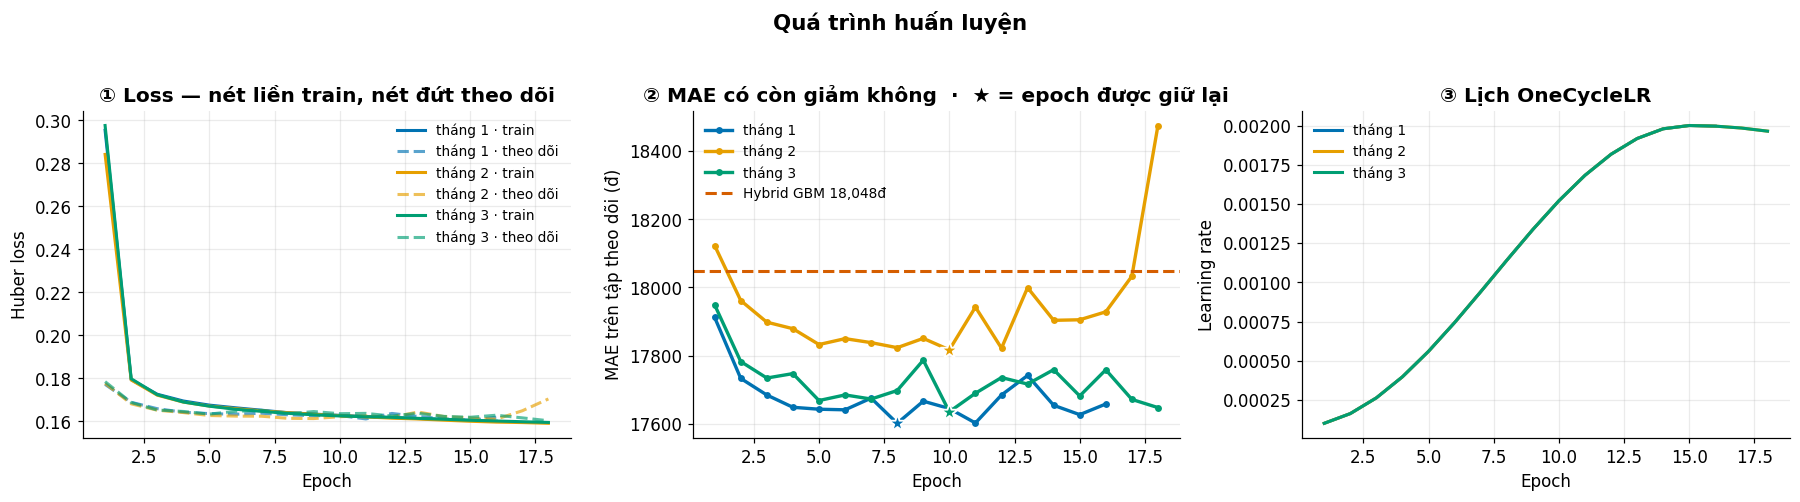

  Tháng 1: chạy 16/50 epoch · giữ lại epoch 8  (dừng sớm)
           loss cuối train 0.16000 · theo dõi 0.16186 · chênh +0.00186
           10.8 phút · 41s mỗi epoch
  Tháng 2: chạy 18/50 epoch · giữ lại epoch 10  (dừng sớm)
           loss cuối train 0.15901 · theo dõi 0.17035 · chênh +0.01134
           12.2 phút · 41s mỗi epoch
  Tháng 3: chạy 18/50 epoch · giữ lại epoch 10  (dừng sớm)
           loss cuối train 0.15942 · theo dõi 0.16020 · chênh +0.00078
           12.2 phút · 41s mỗi epoch


In [21]:
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "font.size": 11,
    "figure.dpi": 110, "savefig.bbox": "tight"})
BLUE, ORANGE, GREEN, RED, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#666"

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))
MAU_T = [BLUE, ORANGE, GREEN]
for k, c in zip(KQ, MAU_T):
    h = k["lich_su"]
    ax[0].plot(h["epoch"], h["loss_train"], lw=2, color=c,
               label=f"tháng {k['thang']} · train")
    ax[0].plot(h["epoch"], h["loss_valid"], lw=2, ls="--", color=c, alpha=.65,
               label=f"tháng {k['thang']} · theo dõi")
    ax[1].plot(h["epoch"], h["mae_valid"], lw=2.2, marker="o", ms=3.5, color=c,
               label=f"tháng {k['thang']}")
    e = k["epoch_tot_nhat"]
    ax[1].scatter([e], [h["mae_valid"][e-1]], s=140, marker="*", color=c,
                  zorder=5, edgecolors="white", linewidths=1.2)
    ax[2].plot(h["epoch"], h["lr"], lw=2, color=c, label=f"tháng {k['thang']}")

ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Huber loss")
ax[0].legend(frameon=False, fontsize=9, ncol=1)
ax[0].set_title("① Loss — nét liền train, nét đứt theo dõi", fontweight="bold")

ax[1].axhline(MOC["hybrid"], color=RED, lw=2, ls="--",
              label=f"Hybrid GBM {MOC['hybrid']:,}đ")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("MAE trên tập theo dõi (đ)")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("② MAE có còn giảm không  ·  ★ = epoch được giữ lại",
                fontweight="bold")

ax[2].set_xlabel("Epoch"); ax[2].set_ylabel("Learning rate")
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Lịch OneCycleLR", fontweight="bold")

fig.suptitle("Quá trình huấn luyện", fontweight="bold", fontsize=14, y=1.03)
plt.tight_layout(); plt.savefig("qua_trinh_train.png"); plt.show()

for k in KQ:
    h = k["lich_su"]
    kc = h["loss_valid"][-1] - h["loss_train"][-1]
    print(f"  Tháng {k['thang']}: chạy {k['so_epoch_chay']}/{CAU_HINH['epochs']} epoch"
          f" · giữ lại epoch {k['epoch_tot_nhat']}"
          f"{'  (dừng sớm)' if k['so_epoch_chay'] < CAU_HINH['epochs'] else ''}")
    print(f"           loss cuối train {h['loss_train'][-1]:.5f} · "
          f"theo dõi {h['loss_valid'][-1]:.5f} · chênh {kc:+.5f}"
          f"{'  ⚠️ có dấu hiệu overfit' if kc > .02 else ''}")
    print(f"           {sum(h['giay'])/60:.1f} phút · "
          f"{sum(h['giay'])/len(h['giay']):.0f}s mỗi epoch")

## 6. Kết quả trên tập test

Tập test **chưa từng dùng** để huấn luyện hay chọn tham số.

In [22]:
n_tong = sum(k["n_test"] for k in KQ)
mae_tf = sum(k["mae"]*k["n_test"] for k in KQ) / n_tong
mape_tf = sum(k["mape"]*k["n_test"] for k in KQ) / n_tong

P = np.concatenate([k["pred"] for k in KQ])
Y = np.concatenate([k["that"] for k in KQ])
IDX = np.concatenate([k["idx_test"] for k in KQ])
r2_tf = 1 - ((Y-P)**2).sum() / ((Y-Y.mean())**2).sum()

BANG = pd.DataFrame([
    {"Model": "Persistence", "MAE": MOC["persistence"], "MAPE": np.nan},
    {"Model": "Dự đoán trực tiếp (GBM)", "MAE": MOC["truc_tiep"], "MAPE": np.nan},
    {"Model": "Hybrid GBM (đang dùng)", "MAE": MOC["hybrid"], "MAPE": MOC["hybrid_mape"]},
    {"Model": "TRANSFORMER", "MAE": mae_tf, "MAPE": mape_tf},
])
BANG["So với Hybrid"] = BANG.MAE / MOC["hybrid"] - 1
display(BANG.style.format({"MAE": "{:,.0f}đ", "MAPE": "{:.2%}",
                           "So với Hybrid": "{:+.2%}"}, na_rep="—")
        .hide(axis="index"))

print(f"\nTừng tháng:")
for k in KQ:
    print(f"  Tháng {k['thang']}: MAE {k['mae']:>8,.0f}đ · MAPE {k['mape']:.2%} "
          f"· R² {k['r2']:.4f} · n {k['n_test']:,}")
print(f"\nGỘP: MAE {mae_tf:,.0f}đ · MAPE {mape_tf:.2%} · R² {r2_tf:.4f} · n {n_tong:,}")
print("="*66)
if mae_tf < MOC["hybrid"]:
    print(f"  ✅ Transformer THẮNG Hybrid {1-mae_tf/MOC['hybrid']:.2%}")
    print("     → đáng đưa vào pipeline, chạy thêm cấu hình khác để tối ưu")
else:
    print(f"  ❌ Transformer thua Hybrid {mae_tf/MOC['hybrid']-1:.2%}")
    print("     → chuỗi thô KHÔNG mang thêm thông tin so với 3 con số tóm tắt.")
    print("     Ghi vào báo cáo: model đã chạm trần bộ dữ liệu này,")
    print("     việc tiếp theo là thêm NGUỒN DỮ LIỆU MỚI, không phải đổi kiến trúc.")

Model,MAE,MAPE,So với Hybrid
Persistence,"33,683đ",—,+86.63%
Dự đoán trực tiếp (GBM),"18,834đ",—,+4.36%
Hybrid GBM (đang dùng),"18,048đ",14.74%,+0.00%
TRANSFORMER,"18,008đ",14.80%,-0.22%



Từng tháng:
  Tháng 1: MAE   17,846đ · MAPE 14.87% · R² 0.7341 · n 315,360
  Tháng 2: MAE   17,868đ · MAPE 14.76% · R² 0.7351 · n 234,632
  Tháng 3: MAE   18,275đ · MAPE 14.76% · R² 0.7287 · n 314,368

GỘP: MAE 18,008đ · MAPE 14.80% · R² 0.7326 · n 864,360
  ✅ Transformer THẮNG Hybrid 0.22%
     → đáng đưa vào pipeline, chạy thêm cấu hình khác để tối ưu


## 7. Trực quan kết quả đánh giá

Bốn góc nhìn, mỗi cái trả lời một câu khác nhau.

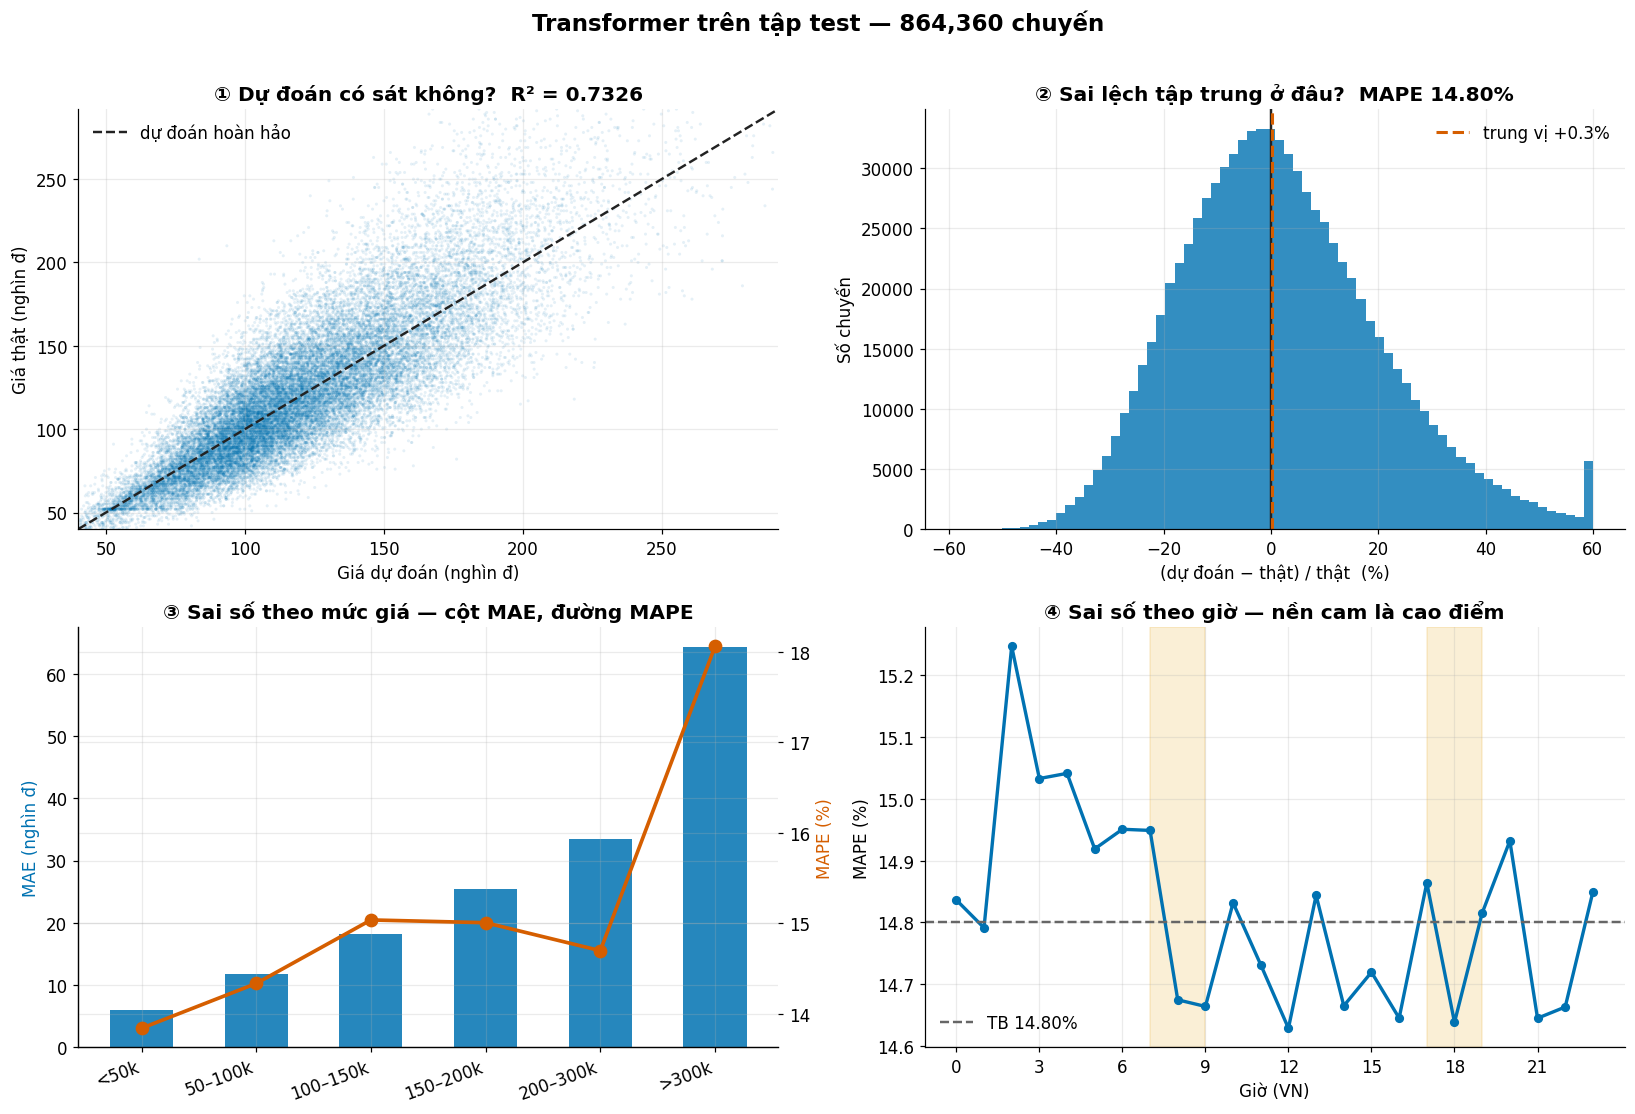

    Band giá         n         MAE     MAPE
---------------------------------------------
        <50k    10,441      6,054đ   13.84%
     50–100k   259,587     11,785đ   14.34%
    100–150k   412,662     18,288đ   15.04%
    150–200k   152,123     25,421đ   15.01%
    200–300k    28,261     33,496đ   14.70%
       >300k     1,286     64,283đ   18.06%


In [23]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
rng = np.random.default_rng(0)
sub = rng.choice(len(P), min(30000, len(P)), replace=False)

# ① Tán xạ dự đoán vs thật
a = ax[0, 0]
lo, hi = np.percentile(Y, .5), np.percentile(Y, 99.5)
a.scatter(P[sub]/1000, Y[sub]/1000, s=4, alpha=.10, color=BLUE, edgecolors="none")
a.plot([lo/1000, hi/1000], [lo/1000, hi/1000], color="#222", lw=1.6, ls="--",
       label="dự đoán hoàn hảo")
a.set_xlim(lo/1000, hi/1000); a.set_ylim(lo/1000, hi/1000)
a.set_xlabel("Giá dự đoán (nghìn đ)"); a.set_ylabel("Giá thật (nghìn đ)")
a.legend(frameon=False)
a.set_title(f"① Dự đoán có sát không?  R² = {r2_tf:.4f}", fontweight="bold")

# ② Phân bố sai số tương đối
a = ax[0, 1]
e = (P - Y) / Y
a.hist(np.clip(e, -.6, .6)*100, bins=70, color=BLUE, alpha=.8)
a.axvline(0, color="#222", lw=1.6)
a.axvline(np.median(e)*100, color=RED, lw=2, ls="--",
          label=f"trung vị {np.median(e):+.1%}")
a.set_xlabel("(dự đoán − thật) / thật  (%)"); a.set_ylabel("Số chuyến")
a.legend(frameon=False)
a.set_title(f"② Sai lệch tập trung ở đâu?  MAPE {mape_tf:.2%}", fontweight="bold")

# ③ MAE theo band giá
a = ax[1, 0]
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
b = pd.cut(P, CANH, labels=TEN)
g = pd.DataFrame({"b": b, "ae": np.abs(P-Y), "re": np.abs(P-Y)/Y}).groupby(
    "b", observed=True).agg(mae=("ae", "mean"), mape=("re", "mean"),
                            n=("ae", "size")).reindex(TEN)
x = np.arange(len(TEN))
a.bar(x, g.mae/1000, .55, color=BLUE, alpha=.85)
a2 = a.twinx()
a2.plot(x, g.mape*100, marker="o", ms=8, lw=2.4, color=RED)
a2.set_ylabel("MAPE (%)", color=RED)
a.set_xticks(x); a.set_xticklabels(TEN, rotation=20, ha="right")
a.set_ylabel("MAE (nghìn đ)", color=BLUE)
a.set_title("③ Sai số theo mức giá — cột MAE, đường MAPE", fontweight="bold")

# ④ MAPE theo giờ
a = ax[1, 1]
gio = mau.gio.values[IDX]
gg = pd.DataFrame({"g": gio, "re": np.abs(P-Y)/Y}).groupby("g").re.mean()
for h1, h2 in [(7, 9), (17, 19)]:
    a.axvspan(h1, h2, color=ORANGE, alpha=.16, zorder=0)
a.plot(gg.index, gg*100, marker="o", ms=5, lw=2.2, color=BLUE)
a.axhline(mape_tf*100, color=MUT, lw=1.6, ls="--", label=f"TB {mape_tf:.2%}")
a.set_xticks(range(0, 24, 3)); a.set_xlabel("Giờ (VN)")
a.set_ylabel("MAPE (%)"); a.legend(frameon=False)
a.set_title("④ Sai số theo giờ — nền cam là cao điểm", fontweight="bold")

fig.suptitle(f"Transformer trên tập test — {n_tong:,} chuyến",
             fontweight="bold", fontsize=15, y=1.01)
plt.tight_layout(); plt.savefig("ket_qua_test.png"); plt.show()

print(f"{'Band giá':>12s} {'n':>9s} {'MAE':>11s} {'MAPE':>8s}")
print("-"*45)
for t in TEN:
    r = g.loc[t]
    if np.isfinite(r.n):
        print(f"{t:>12s} {int(r.n):>9,} {r.mae:>10,.0f}đ {r.mape:>8.2%}")

## 8. Xuất model để tải về máy

Lưu vào `/kaggle/working/` — sau khi **Save Version**, vào tab **Output** để tải về.

Mỗi tháng một file `.pt` chứa:

| Thành phần | Vì sao cần |
|---|---|
| `state_dict` | Trọng số model |
| `cau_hinh` | Để dựng lại đúng kiến trúc |
| `mu`, `sd` | Chuẩn hoá đặc trưng tĩnh — **không có thì dự đoán sai** |
| `mu_s`, `sd_s` | Chuẩn hoá chuỗi |
| `cot_seq`, `cot_so`, `danh_muc` | Thứ tự cột, tránh ghép nhầm |

In [24]:
import zipfile
THU_MUC = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
os.makedirs(f"{THU_MUC}/model_transformer", exist_ok=True)

for k in KQ:
    torch.save({
        "state_dict": k["model"].state_dict(),
        "cau_hinh": CAU_HINH,
        "thang": k["thang"],
        "mu": k["mu"].cpu().numpy(), "sd": k["sd"].cpu().numpy(),
        "mu_s": k["mu_s"].cpu().numpy(), "sd_s": k["sd_s"].cpu().numpy(),
        # chuẩn hoá MỤC TIÊU — thiếu bốn số này thì dự đoán ra rác
        "mu_b": float(k["mu_b"]), "sd_b": float(k["sd_b"]),
        "mu_h": float(k["mu_h"]), "sd_h": float(k["sd_h"]),
        "cot_seq": COT_SEQ, "cot_so": SO, "danh_muc": DANH_MUC,
        "ket_qua": {"mae": k["mae"], "mape": k["mape"], "r2": k["r2"],
                    "n_test": k["n_test"]},
    }, f"{THU_MUC}/model_transformer/transformer_thang{k['thang']}.pt")
    print(f"  Đã lưu transformer_thang{k['thang']}.pt")

tom_tat = {
    "mo_ta": "Transformer dự báo giá đối thủ TP.HCM — train riêng từng tháng",
    "cau_hinh": CAU_HINH,
    "ket_qua_gop": {"mae": float(mae_tf), "mape": float(mape_tf),
                    "r2": float(r2_tf), "n_test": int(n_tong)},
    "tung_thang": [{"thang": k["thang"], "mae": float(k["mae"]),
                    "mape": float(k["mape"]), "r2": float(k["r2"])} for k in KQ],
    "moc_so_sanh": MOC,
    "ket_luan": ("THANG Hybrid" if mae_tf < MOC["hybrid"] else "THUA Hybrid"),
}
# encoding="utf-8" bắt buộc — không có thì hỏng trên Windows khi tải về mở lại
json.dump(tom_tat, open(f"{THU_MUC}/model_transformer/tom_tat.json", "w",
                        encoding="utf-8"), ensure_ascii=False, indent=1)

lich = {f"thang_{k['thang']}": k["lich_su"] for k in KQ}
json.dump(lich, open(f"{THU_MUC}/model_transformer/lich_su_train.json", "w",
                     encoding="utf-8"), ensure_ascii=False, indent=1)

with zipfile.ZipFile(f"{THU_MUC}/model_transformer.zip", "w",
                     zipfile.ZIP_DEFLATED) as z:
    for f in sorted(os.listdir(f"{THU_MUC}/model_transformer")):
        z.write(f"{THU_MUC}/model_transformer/{f}", f)
    for f in ["qua_trinh_train.png", "ket_qua_test.png"]:
        if os.path.exists(f"{THU_MUC}/{f}"):
            z.write(f"{THU_MUC}/{f}", f)

kb = os.path.getsize(f"{THU_MUC}/model_transformer.zip")/1024/1024
print(f"\n📦 model_transformer.zip — {kb:.1f} MB")
print("   Save Version → tab Output → tải file này về")

  Đã lưu transformer_thang1.pt
  Đã lưu transformer_thang2.pt
  Đã lưu transformer_thang3.pt

📦 model_transformer.zip — 1.5 MB
   Save Version → tab Output → tải file này về


### Nạp lại model ở máy

```python
import torch, numpy as np

goi = torch.load("transformer_thang3.pt", map_location="cpu", weights_only=False)
model = TransformerGia(goi["cau_hinh"])       # cần dán lại class TransformerGia
model.load_state_dict(goi["state_dict"])
model.eval()

# Chuẩn hoá phải dùng ĐÚNG thống kê đã lưu, không tính lại trên dữ liệu mới
x  = (chuoi - goi["mu_s"]) / goi["sd_s"]
so = (dac_trung_tinh - goi["mu"]) / goi["sd"]

with torch.no_grad():
    z_base, z_heso = model(x, mask, danh_muc, so)
    # BỎ chuẩn hoá mục tiêu — model xuất ra z-score, không phải giá trị thật
    gia = torch.exp(z_base * goi["sd_b"] + goi["mu_b"]) * \
          (z_heso * goi["sd_h"] + goi["mu_h"])
```

> **Hai bẫy hay gặp:**
>
> 1. Tính lại `mean/std` trên dữ liệu mới thay vì dùng thống kê đã lưu → model nhận đầu vào lệch
>    thang đo, dự đoán sai lệch có hệ thống.
> 2. Quên bỏ chuẩn hoá **mục tiêu** — model xuất ra z-score chứ không phải `log(giá)`. Quên bước
>    này thì `exp(z)` ra vài đơn vị đồng thay vì trăm nghìn.

### Nếu muốn thử cấu hình khác

Sửa `CAU_HINH` ở phần 1 rồi **Run All**:

| Thử | Đổi gì | Đáng thử? |
|---|---|---|
| `K: 64` | Phủ hết 60 phút thay vì ~23 phút | ⭐ đáng nhất |
| `epochs: 20` | Train lâu hơn — xem đường MAE ở hình ② còn dốc không | Vừa |
| `d_model: 128`, `n_lop: 4` | Model to hơn | Thấp — dữ liệu là nút thắt, không phải sức chứa |
| Bỏ `h60_*` khỏi `SO` | Ép model phải dùng chuỗi, tránh nó lười dùng lại tóm tắt | ⭐ đáng thử |